In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq

In [4]:
df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25.csv')

In [5]:
books = pd.read_csv('../../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

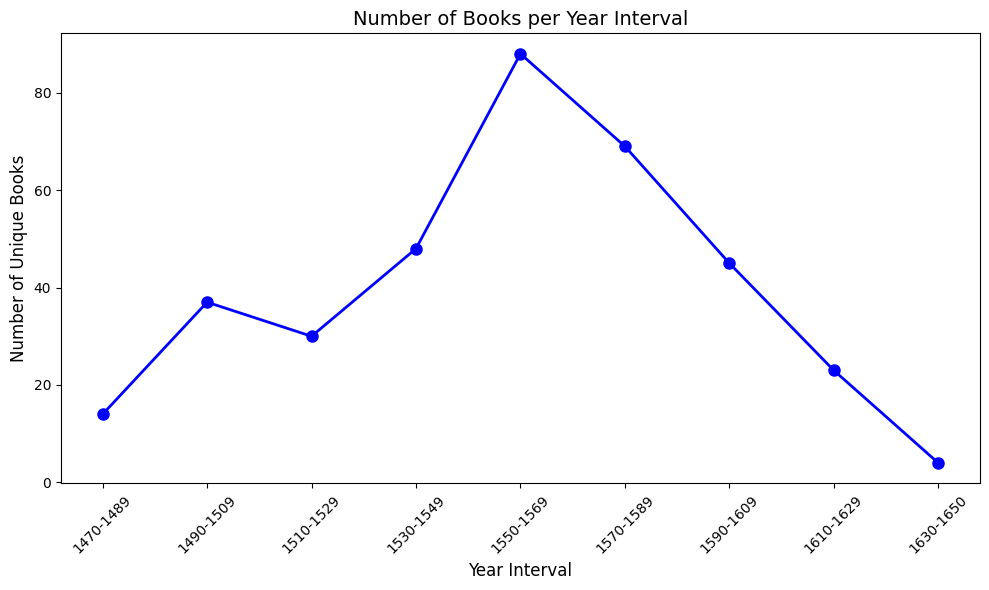

In [7]:

# Group by 'year_interval' and count the unique books
unique_books_per_interval = books.groupby('year_interval')['book'].nunique()

# Ensure the intervals are ordered correctly based on the 'year_interval' in your data
ordered_intervals = pd.Categorical(unique_books_per_interval.index, ordered=True)

# Reorder the Series by the correct order of 'year_interval'
unique_books_per_interval = unique_books_per_interval[ordered_intervals]

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(unique_books_per_interval.index, unique_books_per_interval, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)

# Improve the plot (labels, title, etc.)
plt.title('Number of Books per Year Interval', fontsize=14)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Unique Books', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to avoid clipping of labels

figures/plots/context_quantitative_overview/num_books

# Show the plot
plt.show()


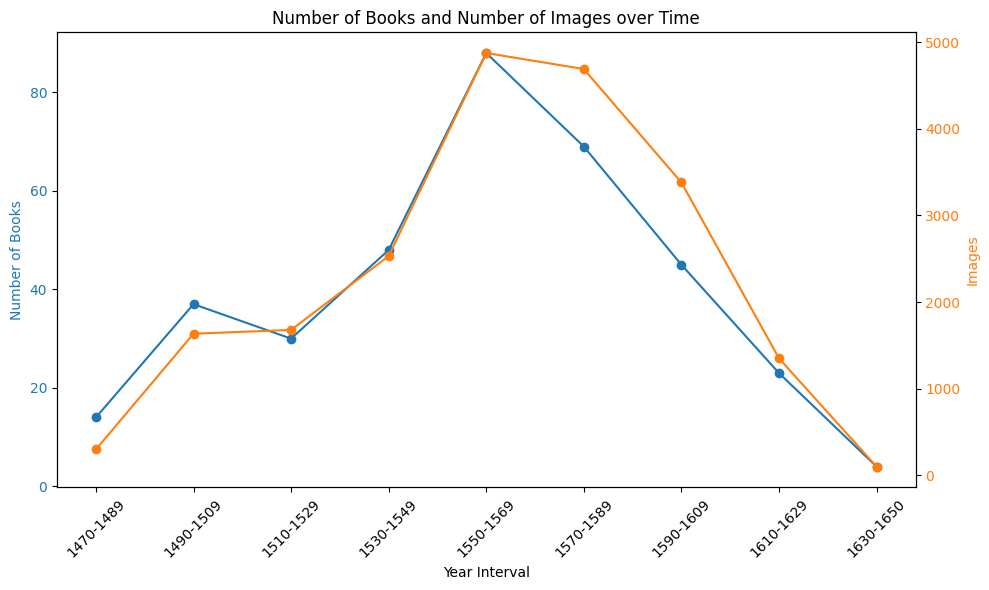

In [9]:

# Line 1: Number of unique book values per interval in books
book_counts = books.groupby('year_interval', observed=False)['book'].nunique()

# Line 2: Number of unique image values per interval in df
image_counts = df.groupby('year_interval', observed=False)['images'].nunique()

# Create the plot with two Y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first line (unique books) on the left Y-axis
ax1.plot(book_counts.index, book_counts.values, label='Unique Books', marker='o', color='tab:blue')
ax1.set_xlabel('Year Interval')
ax1.set_ylabel('Number of Books', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second Y-axis to plot unique images
ax2 = ax1.twinx()  
ax2.plot(image_counts.index, image_counts.values, label='Images', marker='o', color='tab:orange')
ax2.set_ylabel('Images', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Customize the plot
plt.title('Number of Books and Number of Images over Time')

# Adjust x-axis labels to show rotated years without the warning
ax1.set_xticks(range(len(book_counts.index)))  # Set the tick positions
ax1.set_xticklabels(book_counts.index, rotation=45)  # Set the labels

fig.tight_layout()

# Show the plot
plt.show()


In [ ]:


# 1. Number of unique books per time interval (from the 'books' dataframe)
book_counts_per_bin = books.groupby('year_bin', observed=False)['book'].nunique()

# 2. Calculate the total number of unique images for each book per time interval (from the 'df' dataframe)
# Group by 'year_bin' and 'book' to count unique images associated with each book
book_image_counts = df.groupby(['year_interval', 'book'], observed=False)['images'].nunique()

# 3. For each year_bin, calculate the total number of unique images
total_images_per_bin = book_image_counts.groupby('year_interval', observed=False).sum()

# 4. Calculate the average number of unique images per unique book in each time interval
avg_images_per_book_per_bin = total_images_per_bin / book_counts_per_bin

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the number of unique books per time interval
ax.plot(book_counts_per_bin.index, book_counts_per_bin.values, label='Unique Books', marker='o', color='tab:blue')

# Plot the average number of unique images per book
ax.plot(avg_images_per_book_per_bin.index, avg_images_per_book_per_bin.values, label='Avg Unique Images per Book', marker='o', color='tab:orange')

# Labeling the axes
ax.set_xlabel('Time Interval (20-year bins)')
ax.set_ylabel('Count', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# Add title and rotate x-ticks for better readability
plt.title('Unique Books and Avg Unique Images per Book over Time')

# Set x-ticks explicitly so they match the number of bins and avoid the warning
ax.set_xticks(range(len(book_counts_per_bin.index)))
ax.set_xticklabels(book_counts_per_bin.index, rotation=45)

# Add legends for both lines
ax.legend(loc='upper left')

# Adjust layout for better spacing
fig.tight_layout()

# Show the plot
plt.show()


In [ ]:
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/ave_image_book.png')